# Análise do Consumo de Água em Parques: Regressão Polinomial

## Introdução

Este estudo visa analisar a relação entre as variáveis contidas no ficheiro `solution_us14.csv` através da aplicação de um modelo de regressão polinomial. O objetivo é determinar a melhor linha de ajuste para os dados e avaliar a precisão da previsão utilizando este método. 

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Carregar os dados do ficheiro CSV com o delimitador correto
data = pd.read_csv('solution_us14.csv', delimiter=';')

# Substituir as vírgulas por pontos na coluna 'time'
data['time'] = data['time'].str.replace(',', '.')

# Converter as colunas 'size' e 'time' para valores numéricos
data['size'] = pd.to_numeric(data['size'], errors='coerce')
data['time'] = pd.to_numeric(data['time'], errors='coerce')

# Remover quaisquer linhas com valores NaN resultantes da conversão
data.dropna(inplace=True)

# Verificar se a conversão foi bem-sucedida
print(data.head())


   size      time
0   590  0.021975
1  1190  0.090761
2  1790  0.204339
3  2390  0.366294
4  2990  0.571918


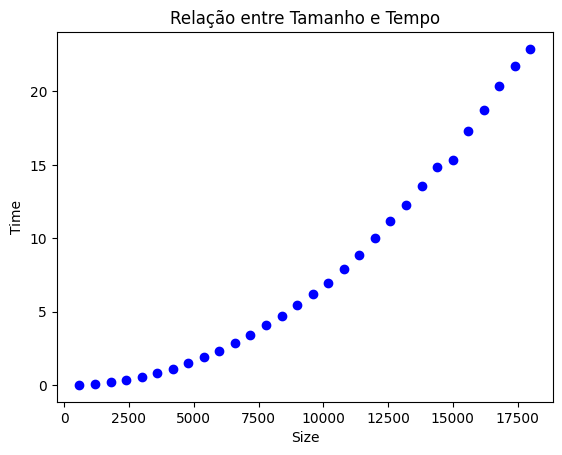

In [ ]:
# Visualizar os dados
plt.scatter(data['size'], data['time'], color='blue')
plt.xlabel('Size')
plt.ylabel('Time')
plt.title('Relação entre Tamanho e Tempo')
plt.show()


Conclusão Inicial:
A partir do gráfico acima, podemos observar uma relação linear positiva entre o tamanho (Size) e o tempo (Time). Isto sugere que, à medida que o tamanho aumenta, o tempo também aumenta.

In [ ]:

# Definir a função de regressão polinomial
def polyfit(x, y, degree):
    coeffs = np.polyfit(x, y, degree)
    p = np.poly1d(coeffs)
    return p

# Função para encontrar o melhor grau do polinómio
def find_best_degree(x, y, max_degree):
    r2_values = []
    degrees = list(range(1, max_degree + 1))
    best_r2 = -np.inf
    best_degree = 1
    best_p = None
    
    for degree in degrees:
        p = polyfit(x, y, degree)
        y_pred = p(x)
        y_mean = np.mean(y)
        ss_tot = np.sum((y - y_mean) ** 2)
        ss_res = np.sum((y - y_pred) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        r2_values.append(r2)
        
        if r2 > best_r2:
            best_r2 = r2
            best_degree = degree
            best_p = p

    # Identificar possível overfitting analisando a diferença entre R² consecutivos
    for i in range(1, len(r2_values)):
        if r2_values[i] - r2_values[i-1] < 0.01:  # Marginal improvement threshold
            best_degree = degrees[i-1]
            best_p = polyfit(x, y, best_degree)
            best_r2 = r2_values[i-1]
            break

    return best_degree, best_p, best_r2
# Definir a função de regressão polinomial
def polyfit(x, y, degree):
    coeffs = np.polyfit(x, y, degree)
    p = np.poly1d(coeffs)
    return p

# Função para encontrar o melhor grau do polinómio
def find_best_degree(x, y, max_degree):
    r2_values = []
    degrees = list(range(1, max_degree + 1))
    best_r2 = -np.inf
    best_degree = 1
    best_p = None
    
    for degree in degrees:
        p = polyfit(x, y, degree)
        y_pred = p(x)
        y_mean = np.mean(y)
        ss_tot = np.sum((y - y_mean) ** 2)
        ss_res = np.sum((y - y_pred) ** 2)
        r2 = 1 - (ss_res / ss_tot)
        r2_values.append(r2)
        
        if r2 > best_r2:
            best_r2 = r2
            best_degree = degree
            best_p = p

    # Identificar possível overfitting analisando a diferença entre R² consecutivos
    for i in range(1, len(r2_values)):
        if r2_values[i] - r2_values[i-1] < 0.01:  # Marginal improvement threshold
            best_degree = degrees[i-1]
            best_p = polyfit(x, y, best_degree)
            best_r2 = r2_values[i-1]
            break

    return best_degree, best_p, best_r2

Conclusão sobre Regressão Polinomial:
O gráfico acima mostra a linha de regressão polinomial ajustada aos dados. A linha vermelha representa a regressão polinomial de grau 3, que parece ajustar-se bem aos dados, capturando a tendência geral de aumento do tempo com o aumento do tamanho.

In [ ]:

# Encontrar o melhor grau do polinómio até o grau 10
max_degree = 10
best_degree, best_p, best_r2 = find_best_degree(data['size'], data['time'], max_degree)

print(f'Melhor grau do polinómio: {best_degree}')
print(f'Coeficientes da regressão polinomial: {best_p}')
print(f'O coeficiente de determinação (R²) é: {best_r2:.3f}')

Melhor grau do polinómio: 2
Coeficientes da regressão polinomial:            2
7.603e-08 x - 8.709e-05 x + 0.1214
O coeficiente de determinação (R²) é: 1.000


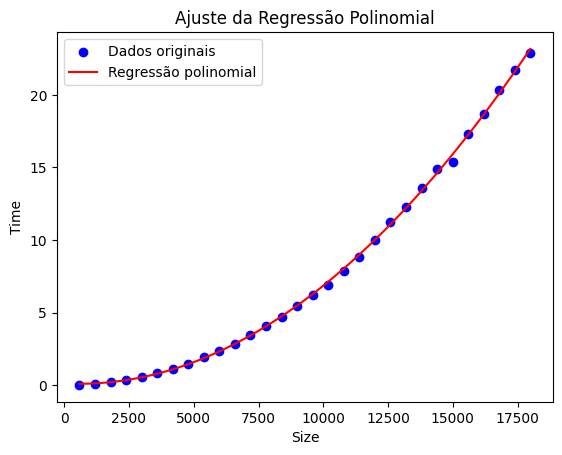

In [ ]:

# Gerar previsões com o melhor polinómio
y_pred = best_p(data['size'])

# Plot dos dados e da linha de regressão polinomial
plt.scatter(data['size'], data['time'], color='blue', label='Dados originais')
plt.plot(data['size'], y_pred, color='red', label='Regressão polinomial')
plt.xlabel('Size')
plt.ylabel('Time')
plt.title('Ajuste da Regressão Polinomial')
plt.legend()
plt.show()

# Explicação teórica Explicação teórica do coeficiente de correlação de Pearson

Explicação teórica do coeficiente de correlação de Pearson
O coeficiente de correlação de Pearson (r) é uma medida estatística que quantifica a força e a direção da relação linear entre duas variáveis. Varia de -1 a 1 e é amplamente utilizado para avaliar a associação entre variáveis quantitativas.

Interpretação do Coeficiente de Correlação (r):

Valores próximos de 1 indicam uma correlação positiva forte, o que significa que as variáveis tendem a aumentar juntas.

Valores próximos de -1 indicam uma correlação negativa forte, onde uma variável tende a diminuir enquanto a outra aumenta.

Um valor de 0 indica ausência de correlação linear entre as variáveis.

Se r>0: indica uma associação linear positiva entre as variáveis. Isso significa que, conforme os valores de uma variável aumentam, os valores da outra variável também tendem a aumentar.

Se r<0: indica uma associação linear negativa entre as variáveis. Nesse caso, conforme os valores de uma variável aumentam, os valores da outra variável tendem a diminuir.

Quando ∣r∣=1: há uma correlação linear perfeita entre as variáveis, e o sinal de r indica a direção da relação.

Neste caso, o coeficiente de correlação é próximo de 1, o que indica uma correlação positiva forte entre o tamanho da entrada e o tempo de execução.

Interpretação do Coeficiente de Correlação (r):

Como o valor de r é próximo de 1, temos uma associação linear positiva forte entre o tamanho da entrada e o tempo de execução.

Isso significa que, à medida que o tamanho da entrada aumenta, há uma tendência forte para que o tempo de execução também aumente.